In [ ]:
import os, zipfile
import numpy as np
import tensorflow as tf
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

from google.colab import drive
drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

BASE = "/content/dataset/Parkinson's Dataset Final"
print("Extracted BASE folders:", os.listdir(BASE))


Mounted at /content/drive
Extracted BASE folders: ['New hand pd Dataset', 'Hand Pd']


In [ ]:
!pip -q install imagehash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.8 MB/s eta 0:00:00


In [ ]:
import imagehash
from PIL import Image
from collections import defaultdict

NEWHANDPD_ROOT = os.path.join(BASE, "New hand pd Dataset")
HEALTHY_ROOT = os.path.join(NEWHANDPD_ROOT, "Healthy")
PARK_ROOT = os.path.join(NEWHANDPD_ROOT, "Parkinson's")

image_paths_new = []
labels_new = []

def collect_images(root, label):
    for r, d, files in os.walk(root):
        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                image_paths_new.append(os.path.join(r, f))
                labels_new.append(label)

collect_images(HEALTHY_ROOT, 0)
collect_images(PARK_ROOT, 1)

print("NewHandPD total:", len(image_paths_new))
print("Healthy:", labels_new.count(0))
print("Parkinson:", labels_new.count(1))


def get_phash(img_path):
    try:
        img = Image.open(img_path).convert("L").resize((224,224))
        return imagehash.phash(img)
    except:
        return None


PHASH_DISTANCE_THRESHOLD = 4

hash_to_paths = defaultdict(list)

for p in tqdm(image_paths_new, desc="Hashing NewHandPD"):
    h = get_phash(p)
    if h is not None:
        hash_to_paths[str(h)].append(p)

hash_list = list(hash_to_paths.keys())
used = set()
final_keep_hashes = []

for i in tqdm(range(len(hash_list)), desc="Removing near duplicates NewHandPD"):
    if hash_list[i] in used:
        continue

    base_hash = imagehash.hex_to_hash(hash_list[i])
    used.add(hash_list[i])
    final_keep_hashes.append(hash_list[i])

    for j in range(i+1, len(hash_list)):
        if hash_list[j] in used:
            continue
        compare_hash = imagehash.hex_to_hash(hash_list[j])
        if base_hash - compare_hash <= PHASH_DISTANCE_THRESHOLD:
            used.add(hash_list[j])

path_to_label_new = dict(zip(image_paths_new, labels_new))

clean_paths_newhandpd = []
clean_labels_newhandpd = []

for h in final_keep_hashes:
    p = hash_to_paths[h][0]
    clean_paths_newhandpd.append(p)
    clean_labels_newhandpd.append(path_to_label_new[p])

print("\nCLEAN NEWHANDPD")
print("Images:", len(clean_paths_newhandpd))
print("Healthy:", clean_labels_newhandpd.count(0))
print("Parkinson:", clean_labels_newhandpd.count(1))


NewHandPD total: 512
Healthy: 233
Parkinson: 279


Removing near duplicates NewHandPD: 100%|██████████| 467/467 [00:02<00:00, 187.67it/s]


CLEAN NEWHANDPD
Images: 369
Healthy: 190
Parkinson: 179


In [ ]:
HANDPD_ROOT = os.path.join(BASE, "Hand Pd")
SPIRAL_ROOT = os.path.join(HANDPD_ROOT, "Spiral_HandPD")
MEANDER_ROOT = os.path.join(HANDPD_ROOT, "Meander_HandPD")

image_paths_hand = []
labels_hand = []

def collect_handpd(root):
    for cls in os.listdir(root):
        cls_path = os.path.join(root, cls)
        if not os.path.isdir(cls_path):
            continue

        cls_lower = cls.lower()
        if cls_lower == "healthy":
            lab = 0
        elif cls_lower == "parkinson":
            lab = 1
        else:
            continue

        for r, d, files in os.walk(cls_path):
            for f in files:
                if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    image_paths_hand.append(os.path.join(r, f))
                    labels_hand.append(lab)

collect_handpd(SPIRAL_ROOT)
collect_handpd(MEANDER_ROOT)

print("HandPD total:", len(image_paths_hand))
print("Healthy:", labels_hand.count(0))
print("Parkinson:", labels_hand.count(1))


hash_to_paths = defaultdict(list)

for p in tqdm(image_paths_hand, desc="Hashing HandPD"):
    h = get_phash(p)
    if h is not None:
        hash_to_paths[str(h)].append(p)

hash_list = list(hash_to_paths.keys())
used = set()
final_keep_hashes = []

for i in tqdm(range(len(hash_list)), desc="Removing near duplicates HandPD"):
    if hash_list[i] in used:
        continue

    base_hash = imagehash.hex_to_hash(hash_list[i])
    used.add(hash_list[i])
    final_keep_hashes.append(hash_list[i])

    for j in range(i+1, len(hash_list)):
        if hash_list[j] in used:
            continue
        compare_hash = imagehash.hex_to_hash(hash_list[j])
        if base_hash - compare_hash <= PHASH_DISTANCE_THRESHOLD:
            used.add(hash_list[j])

path_to_label_hand = dict(zip(image_paths_hand, labels_hand))

clean_paths_handpd = []
clean_labels_handpd = []

for h in final_keep_hashes:
    p = hash_to_paths[h][0]
    clean_paths_handpd.append(p)
    clean_labels_handpd.append(path_to_label_hand[p])

print("\nCLEAN HANDPD")
print("Images:", len(clean_paths_handpd))
print("Healthy:", clean_labels_handpd.count(0))
print("Parkinson:", clean_labels_handpd.count(1))


HandPD total: 808
Healthy: 216
Parkinson: 592


Removing near duplicates HandPD: 100%|██████████| 735/735 [00:07<00:00, 97.94it/s] 


CLEAN HANDPD
Images: 556
Healthy: 124
Parkinson: 432


In [ ]:
merged_paths = np.array(clean_paths_handpd + clean_paths_newhandpd)
merged_labels = np.array(clean_labels_handpd + clean_labels_newhandpd)

print("\nMERGED CLEAN DATASET")
print("Total:", len(merged_paths))
print("Healthy:", np.sum(merged_labels==0))
print("Parkinson:", np.sum(merged_labels==1))


train_paths, test_paths, y_train, y_test = train_test_split(
    merged_paths, merged_labels,
    test_size=0.20,
    random_state=42,
    stratify=merged_labels
)

val_paths, test_paths, y_val, y_test = train_test_split(
    test_paths, y_test,
    test_size=0.50,
    random_state=42,
    stratify=y_test
)

print("\nSPLIT SUMMARY")
print("Train:", len(train_paths), Counter(y_train))
print("Val  :", len(val_paths), Counter(y_val))
print("Test :", len(test_paths), Counter(y_test))



MERGED CLEAN DATASET
Total: 925
Healthy: 314
Parkinson: 611

SPLIT SUMMARY
Train: 740 Counter({np.int64(1): 489, np.int64(0): 251})
Val  : 92 Counter({np.int64(1): 61, np.int64(0): 31})
Test : 93 Counter({np.int64(1): 61, np.int64(0): 32})


In [ ]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight_dict)


Class weights: {0: 1.4741035856573705, 1: 0.7566462167689162}


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16

def preprocess_image_cv2(path):
    path = path.numpy().decode()

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    # denoise
    img = cv2.fastNlMeansDenoising(img, None, h=10, templateWindowSize=7, searchWindowSize=21)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # normalize ONCE
    img = img.astype(np.float32) / 255.0

    # (224,224,1)
    img = np.expand_dims(img, axis=-1)

    return img

def tf_preprocess(path, label):
    img = tf.py_function(preprocess_image_cv2, [path], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 1))
    label = tf.cast(label, tf.float32)
    return img, label

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(2000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, y_train, training=True)
val_ds   = make_ds(val_paths, y_val, training=False)
test_ds  = make_ds(test_paths, y_test, training=False)

print("tf.data pipeline ready ")


tf.data pipeline ready 


Batch: (16, 224, 224, 1)
Min/Max: 0.039215688 1.0


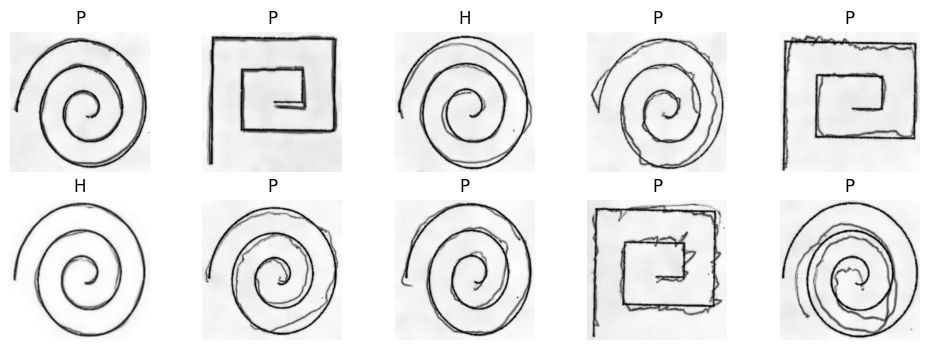

In [ ]:
import matplotlib.pyplot as plt

for imgs, labs in train_ds.take(1):
    print("Batch:", imgs.shape)
    print("Min/Max:", imgs.numpy().min(), imgs.numpy().max())

    plt.figure(figsize=(12,4))
    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(imgs[i].numpy().squeeze(), cmap="gray")
        plt.title("P" if labs[i]==1 else "H")
        plt.axis("off")
    plt.show()


In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
], name="augmentation")


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # 196
EMBED_DIM = 256


class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=16, embed_dim=256, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        self.proj = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )

    def call(self, x):
        x = self.proj(x)  # (B,14,14,D)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])  # (B,196,D)
        return x


class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.repeat(self.cls_token, repeats=batch_size, axis=0)
        x = tf.concat([cls_tokens, x], axis=1)  # (B,197,D)
        x = x + self.pos_embed
        return x


class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout
        )
        self.drop1 = layers.Dropout(dropout)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation=tf.nn.gelu),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        x1 = self.norm1(x)
        attn_out = self.attn(x1, x1, training=training)
        x = x + self.drop1(attn_out, training=training)

        x2 = self.norm2(x)
        x = x + self.mlp(x2, training=training)

        return x


In [ ]:
def build_custom_vit(
    embed_dim=256,
    num_blocks=6,
    num_heads=8,
    mlp_dim=512,
    dropout=0.1
):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = data_augmentation(inputs)

    x = PatchEmbedding(patch_size=PATCH_SIZE, embed_dim=embed_dim, name="patch_embed")(x)
    x = AddPositionEmbedding(num_patches=NUM_PATCHES, embed_dim=embed_dim, name="pos_embed")(x)

    x = layers.Dropout(dropout)(x)

    for i in range(num_blocks):
        x = TransformerEncoder(
            embed_dim=embed_dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout,
            name=f"encoder_{i}"
        )(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)

    cls_out = x[:, 0]  # CLS token

    # Head
    cls_out = layers.Dense(256, activation="relu")(cls_out)
    cls_out = layers.Dropout(0.35)(cls_out)
    cls_out = layers.Dense(64, activation="relu")(cls_out)
    cls_out = layers.Dropout(0.25)(cls_out)

    outputs = layers.Dense(1, activation="sigmoid")(cls_out)

    return keras.Model(inputs, outputs, name="Custom_ViT_PD")


vit_model = build_custom_vit()
vit_model.summary()


Model: "Custom_ViT_PD"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embed (PatchEmbedding)    │ (None, None, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_embed                       │ (None, 197, 256)       │        50,688 │
│ (AddPositionEmbedding)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 197, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_0 (TransformerEncoder)  │ (None, 197, 256)       │       527,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (TransformerEncoder)  │ (None, 197, 256)       │       527,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (TransformerEncoder)  │ (None, 197, 256)       │       527,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_3 (TransformerEncoder)  │ (None, 197, 256)       │       527,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_4 (TransformerEncoder)  │ (None, 197, 256)       │       527,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_5 (TransformerEncoder)  │ (None, 197, 256)       │       527,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_12          │ (None, 197, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,361,921 (12.82 MB)

 Trainable params: 3,361,921 (12.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)

vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
    loss=loss_fn,
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_custom_vit.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]


In [ ]:
history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4488 - auc: 0.4441 - loss: 0.8574
Epoch 1: val_auc improved from -inf to 0.46801, saving model to best_custom_vit.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 278s 4s/step - accuracy: 0.4488 - auc: 0.4444 - loss: 0.8563 - val_accuracy: 0.3370 - val_auc: 0.4680 - val_loss: 0.7195 - learning_rate: 3.0000e-04
Epoch 2/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4886 - auc: 0.5055 - loss: 0.7210
Epoch 2: val_auc improved from 0.46801 to 0.50000, saving model to best_custom_vit.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 238s 4s/step - accuracy: 0.4881 - auc: 0.5053 - loss: 0.7209 - val_accuracy: 0.3370 - val_auc: 0.5000 - val_loss: 0.6941 - learning_rate: 3.0000e-04
Epoch 3/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5147 - auc: 0.5368 - loss: 0.7008
Epoch 3: val_auc did not improve from 0.50000
47/47 ━━━━━━━━━━━━━━━━━━━━ 234s 4s/step - accuracy: 0.5145 - auc: 0.5362 - loss: 0.7009 - val_accuracy: 0.6630 - val_auc: 0.5000 - val_l

KeyboardInterrupt: 